In [ ]:
#Load data
from pathlib import Path
import pandas as pd

path = Path("D:/Learnings/de_project/raw/eda_ecommerce_orders.csv")
df = pd.read_csv(path)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1200 non-null   int64  
 1   customer_id       1200 non-null   int64  
 2   order_date        1200 non-null   object 
 3   product_category  1200 non-null   object 
 4   revenue           1200 non-null   float64
 5   discount          884 non-null    float64
 6   quantity          1200 non-null   int64  
 7   payment_method    1200 non-null   object 
 8   city              1200 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 84.5+ KB


In [18]:
df.head()


,order_id,customer_id,order_date,product_category,revenue,discount,quantity,payment_method,city
0,1,1102,2023-01-07,Groceries,1811.60,151.89,6,Debit Card,Delhi
1,2,1270,2023-05-17,Home,2627.63,92.97,1,Debit Card,Chennai
2,3,1106,2023-06-25,Groceries,465.73,219.60,1,Debit Card,Delhi
3,4,1071,2023-11-24,Home,1243.87,NaN,1,UPI,Bangalore
4,5,1188,2023-11-11,Electronics,1669.33,NaN,1,UPI,Bangalore


In [20]:
df.shape


(1200, 9)

In [21]:
df.describe()


,order_id,customer_id,revenue,discount,quantity
count,1200.000000,1200.000000,1200.000000,884.000000,1200.000000
mean,600.500000,1149.931667,1329.052617,153.460124,3.925833
std,346.554469,86.144962,1161.632987,83.767840,2.027418
min,1.000000,1000.000000,64.280000,10.630000,1.000000
25%,300.750000,1077.000000,521.847500,83.872500,2.000000
50%,600.500000,1149.500000,1005.185000,152.925000,4.000000
75%,900.250000,1224.250000,1769.080000,224.635000,6.000000
max,1200.000000,1299.000000,9354.240000,299.960000,7.000000


In [22]:
df.describe(include="object")


,order_date,product_category,payment_method,city
count,1200,1200,1200,1200
unique,353,5,5,6
top,2023-01-12,Groceries,UPI,Chennai
freq,10,355,428,209


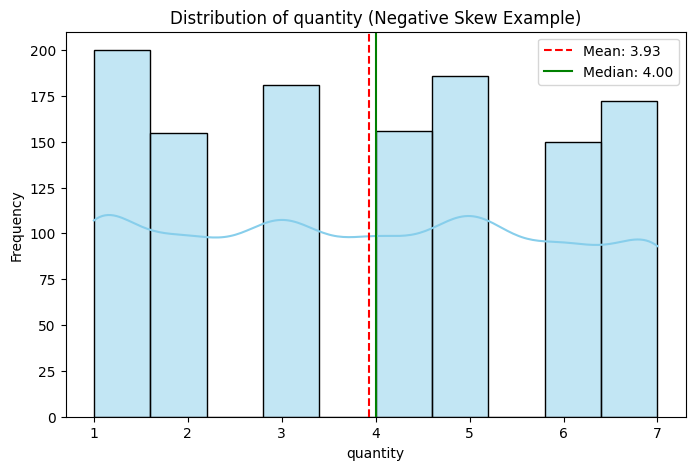

In [ ]:
#plot the quanity Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Replace 'quantity' with the column you identified as negative skew
col = 'quantity'

plt.figure(figsize=(8,5))
sns.histplot(df[col], bins=10, kde=True, color='skyblue')
plt.axvline(df[col].mean(), color='red', linestyle='--', label=f"Mean: {df[col].mean():.2f}")
plt.axvline(df[col].median(), color='green', linestyle='-', label=f"Median: {df[col].median():.2f}")
plt.title(f"Distribution of {col} (Negative Skew Example)")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.legend()
plt.show()


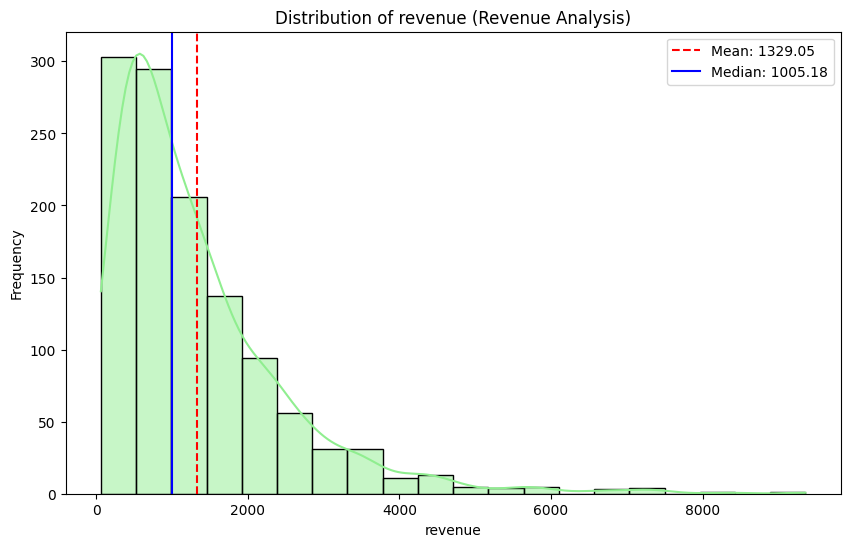

In [ ]:
#plot the revenue distribution
import matplotlib.pyplot as plt
import seaborn as sns

col = 'revenue'

plt.figure(figsize=(10,6))
sns.histplot(df[col], bins=20, kde=True, color='lightgreen')
plt.axvline(df[col].mean(), color='red', linestyle='--', label=f"Mean: {df[col].mean():.2f}")
plt.axvline(df[col].median(), color='blue', linestyle='-', label=f"Median: {df[col].median():.2f}")
plt.title(f"Distribution of {col} (Revenue Analysis)")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [25]:
mean_val = df[col].mean()
median_val = df[col].median()
min_val = df[col].min()
max_val = df[col].max()

print(f"Mean: {mean_val}, Median: {median_val}, Min: {min_val}, Max: {max_val}")


Mean: 1329.0526166666668, Median: 1005.185, Min: 64.28, Max: 9354.24


In [ ]:
#Look at distribution patterns
df['revenue'].value_counts(bins=10)


(54.989000000000004, 993.276]    598
(993.276, 1922.272]              343
(1922.272, 2851.268]             150
(2851.268, 3780.264]              62
(3780.264, 4709.26]               24
(4709.26, 5638.256]                9
(6567.252, 7496.248]               7
(5638.256, 6567.252]               5
(7496.248, 8425.244]               1
(8425.244, 9354.24]                1
Name: count, dtype: int64

In [30]:
df.isna().sum()


order_id              0
customer_id           0
order_date            0
product_category      0
revenue               0
discount            316
quantity              0
payment_method        0
city                  0
dtype: int64

In [31]:
df.isna().sum().sort_values(ascending=False)


discount            316
order_id              0
customer_id           0
product_category      0
order_date            0
revenue               0
quantity              0
payment_method        0
city                  0
dtype: int64

In [ ]:
df[['quantity','discount','revenue']].corr()

,quantity,discount,revenue
quantity,1.000000,-0.084281,0.011129
discount,-0.084281,1.000000,0.008695
revenue,0.011129,0.008695,1.000000


In [40]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

Q1, Q3, lower_limit, upper_limit


(np.float64(521.8475),
 np.float64(1769.08),
 np.float64(-1349.0012500000003),
 np.float64(3639.92875))

In [41]:
Q1 = 1000
Q3 = 4000
lower_limit = -3500
upper_limit = 8500


In [56]:
# Example: create revenue bins
df['revenue_bin'] = pd.qcut(df['revenue'],  q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Count of customers in each bin
df.groupby('revenue_bin')['customer_id'].nunique()


C:\Users\HEMANTH LOKA\AppData\Local\Temp\ipykernel_13588\3067561291.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_bin')['customer_id'].nunique()


revenue_bin
Low          191
Medium       179
High         185
Very High    187
Name: customer_id, dtype: int64

In [57]:
df.groupby('revenue_bin').size()


C:\Users\HEMANTH LOKA\AppData\Local\Temp\ipykernel_13588\2992446539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_bin').size()


revenue_bin
Low          300
Medium       300
High         300
Very High    300
dtype: int64

In [58]:
df.groupby('revenue_bin')['revenue'].sum()


C:\Users\HEMANTH LOKA\AppData\Local\Temp\ipykernel_13588\3250621890.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_bin')['revenue'].sum()


revenue_bin
Low           99879.90
Medium       221074.25
High         400613.65
Very High    873295.34
Name: revenue, dtype: float64

In [63]:
df.groupby('revenue_bin').size()


C:\Users\HEMANTH LOKA\AppData\Local\Temp\ipykernel_13588\2992446539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_bin').size()


revenue_bin
Low          300
Medium       300
High         300
Very High    300
dtype: int64

In [62]:
df.groupby('revenue_bin').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    total_revenue=('revenue', 'sum')
)


C:\Users\HEMANTH LOKA\AppData\Local\Temp\ipykernel_13588\3361897182.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('revenue_bin').agg(


,orders,customers,total_revenue
revenue_bin,,,
Low,300,191,99879.90
Medium,300,179,221074.25
High,300,185,400613.65
Very High,300,187,873295.34


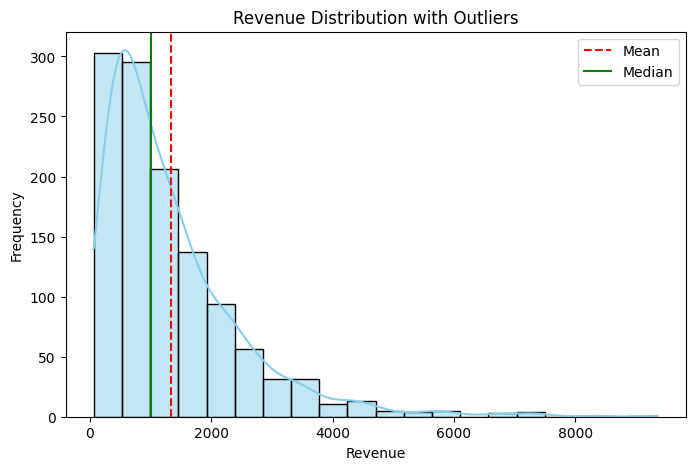

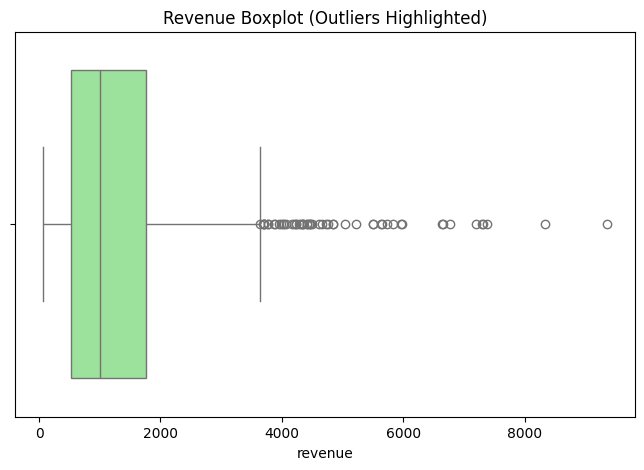

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Revenue Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['revenue'], bins=20, kde=True, color='skyblue')
plt.axvline(df['revenue'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['revenue'].median(), color='green', linestyle='-', label='Median')
plt.title("Revenue Distribution with Outliers")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Example: Boxplot for Outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['revenue'], color='lightgreen')
plt.title("Revenue Boxplot (Outliers Highlighted)")
plt.show()
